# MLP Baseline

#### Load Libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import torch.optim as optim
from torch.utils.data import TensorDataset, random_split
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import seaborn as sns
import matplotlib.pyplot as plt
import os
import joblib
import optuna
from tqdm import tqdm
import sys

os.chdir("/home/jovyan/ds-project-2025/code/model")
print("Current working directory:", os.getcwd())

# Set up device (is available use GPU to speed up computations)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Add code directory to path to import src
# Assuming structure: .../code/model/mlp.ipynb
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
# Or if running from root, append 'code'
if os.path.exists("code"):
    sys.path.append("code")

from src.data import create_data_dict, normalize_data_dict, get_data_loaders
from src.training import EarlyStopping, train_model_mlp
from src.evaluation import evaluate_mlp


Current working directory: /home/jovyan/ds-project-2025/code/model
cuda


## Load Data

In [2]:
train_years = list(range(2006, 2016))  # 10 years
val_years = list(range(2016, 2019))  # 3 years
test_years = list(range(2019, 2023))  # 4 years

data_dict = create_data_dict(
    data_folder="../data/ipc_mean_year_abstract",
    db_path="../data/patent.db",
    score_type="rel",
)

data_dict, norm_stats = normalize_data_dict(data_dict, train_years)

train_loader, val_loader, test_loader = get_data_loaders(
    data_dict, train_years, val_years, test_years
)
print(f"Loaded data for {len(data_dict)} years: {sorted(data_dict.keys())}")


Calculating popularity scores...
Creating global IPC mapping...
Total unique IPC codes: 1989


Processing years: 100%|██████████| 17/17 [00:03<00:00,  4.68it/s]

Normalization fitted on 10 training year(s).
  scalar mean=[83.68548583984375, 73.51998901367188, 0.6721256375312805, 0.0782749280333519, 0.12112732231616974, 0.20387767255306244, 0.19778132438659668, 0.014391365461051464, 0.02158704772591591, 0.1302218735218048, 0.14421346783638, 0.16679991781711578], std=[129.19459533691406, 126.07595825195312, 18.665531158447266, 0.3799460232257843, 0.32627516984939575, 0.40287908911705017, 0.3983263373374939, 0.11909766495227814, 0.14533081650733948, 0.3365473747253418, 0.3513060510158539, 0.3727971315383911]
Train dataset size: 10006
Validation dataset size: 3852
Test dataset size: 5684
Loaded data for 17 years: [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]


In [3]:
# Check the structure of one year's data
sample_year = 2008
print(f"Data for year {sample_year}:")
print(f"Embeddings shape: {data_dict[sample_year].embeddings.shape}")
print(f"Scalar features shape: {data_dict[sample_year].scalar.shape}")
print(f"Targets shape: {data_dict[sample_year].targets.shape}")


Data for year 2008:
Embeddings shape: torch.Size([934, 1024])
Scalar features shape: torch.Size([934, 12])
Targets shape: torch.Size([934])


In [20]:
overfit_loader, _, _ = get_data_loaders(
    data_dict,
    train_years=[2015],
    val_years=[2015],
    test_years=[2015],
    batch_size=64,
)
print(f"Overfit loader: {len(overfit_loader)} batch(es)")


Train dataset size: 1157
Validation dataset size: 1157
Test dataset size: 1157
Overfit loader: 19 batch(es)


## Model Definition

In [4]:
# from torchsummary import summary

emb_dim = data_dict[2006].embeddings.shape[1]
scalar_dim = data_dict[2006].scalar.shape[1]


class MLP(nn.Module):
    def __init__(self, dropout=0.4):
        super(MLP, self).__init__()
        self.emb_net = nn.Sequential(
            nn.Linear(emb_dim + scalar_dim, 1024),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1),
        )

    def forward(self, scalar, emb):
        x = torch.cat([emb, scalar], dim=1)
        return self.emb_net(x)


# Initialize the model with a dropout rate of 0.5
model = MLP(dropout=0.5).to(device)

# # Summary of model structure
# m1_sum = summary(
#     model,
#     input_size=[
#         (scalar_dim,),
#         (emb_dim,),
#     ],
#     device=str(device),
# )


## Training Setup

## Training

### Overfit Test

In [24]:
next(iter(overfit_loader))[0].shape


torch.Size([64, 12])

In [25]:
print("=" * 60)
print("OVERFIT TEST - Pipeline Verification")
print("=" * 60)
print("Goal: Verify that the model can overfit a small dataset")
print("Expected: Loss should decrease rapidly to near 0")
print("=" * 60)

lr = 0.001
weight_decay = 0

model_overfit = MLP(dropout=0).to(device)
epochs = 200
model_path = "mlp_overfit_test.pt"

criterion = nn.L1Loss().to(device)
optimizer = optim.Adam(model_overfit.parameters(), lr=lr, weight_decay=weight_decay)
early_stopper = EarlyStopping(patience=100, path=model_path, printing=True)

train_losses, val_losses = train_model_mlp(
    epochs,
    model_overfit,
    optimizer,
    criterion,
    overfit_loader,
    overfit_loader,
    early_stopper,
    device,
    printing=True,
)

print("OVERFIT TEST COMPLETE")
print("=" * 60)


OVERFIT TEST - Pipeline Verification
Goal: Verify that the model can overfit a small dataset
Expected: Loss should decrease rapidly to near 0
Removing existing model at: mlp_overfit_test.pt
Epoch: 1, Training Loss: 0.2267, Validation Loss: 0.2302
Validation loss decreased (0.230208 --> 0.230208).  Saving model ...
Epoch: 2, Training Loss: 0.2233, Validation Loss: 0.2101
Validation loss decreased (0.230208 --> 0.210072).  Saving model ...
Epoch: 3, Training Loss: 0.2160, Validation Loss: 0.2082
Validation loss decreased (0.210072 --> 0.208198).  Saving model ...
Epoch: 4, Training Loss: 0.1997, Validation Loss: 0.1980
Validation loss decreased (0.208198 --> 0.198042).  Saving model ...
Epoch: 5, Training Loss: 0.2010, Validation Loss: 0.1874
Validation loss decreased (0.198042 --> 0.187428).  Saving model ...
Epoch: 6, Training Loss: 0.1927, Validation Loss: 0.1705
Validation loss decreased (0.187428 --> 0.170548).  Saving model ...
Epoch: 7, Training Loss: 0.1854, Validation Loss: 0.17

C:\Users\samra\AppData\Local\Temp\ipykernel_54440\1471455198.py:1: UserWarning: train_mean not provided for MLP overall-mean baseline. Falling back to the test-set mean — this leaks label information.
  evaluate_mlp(model_overfit, overfit_loader, device, compare_baselines=True)



MODEL: MLP
Number of predictions:            1157
Mean Squared Error (MSE):         0.002864
Root Mean Squared Error (RMSE):   0.053517
Mean Absolute Error (MAE):        0.022765
Median Absolute Error:            0.009063
Mean Absolute Percentage Error:   2043122.35%
R² Score:                         0.969947

BASELINE: Previous Year's Score (Persistence)
Number of predictions:            1157
Mean Squared Error (MSE):         1.077620
Root Mean Squared Error (RMSE):   1.038085
Mean Absolute Error (MAE):        0.735674
Median Absolute Error:            0.560044
Mean Absolute Percentage Error:   206293383.16%
R² Score:                         -10.307835

BASELINE: Overall Mean
Number of predictions:            1157
Mean Squared Error (MSE):         0.095299
Root Mean Squared Error (RMSE):   0.308705
Mean Absolute Error (MAE):        0.233606
Median Absolute Error:            0.186794
Mean Absolute Percentage Error:   16512671.63%
R² Score:                         0.000000

COMPARISON 

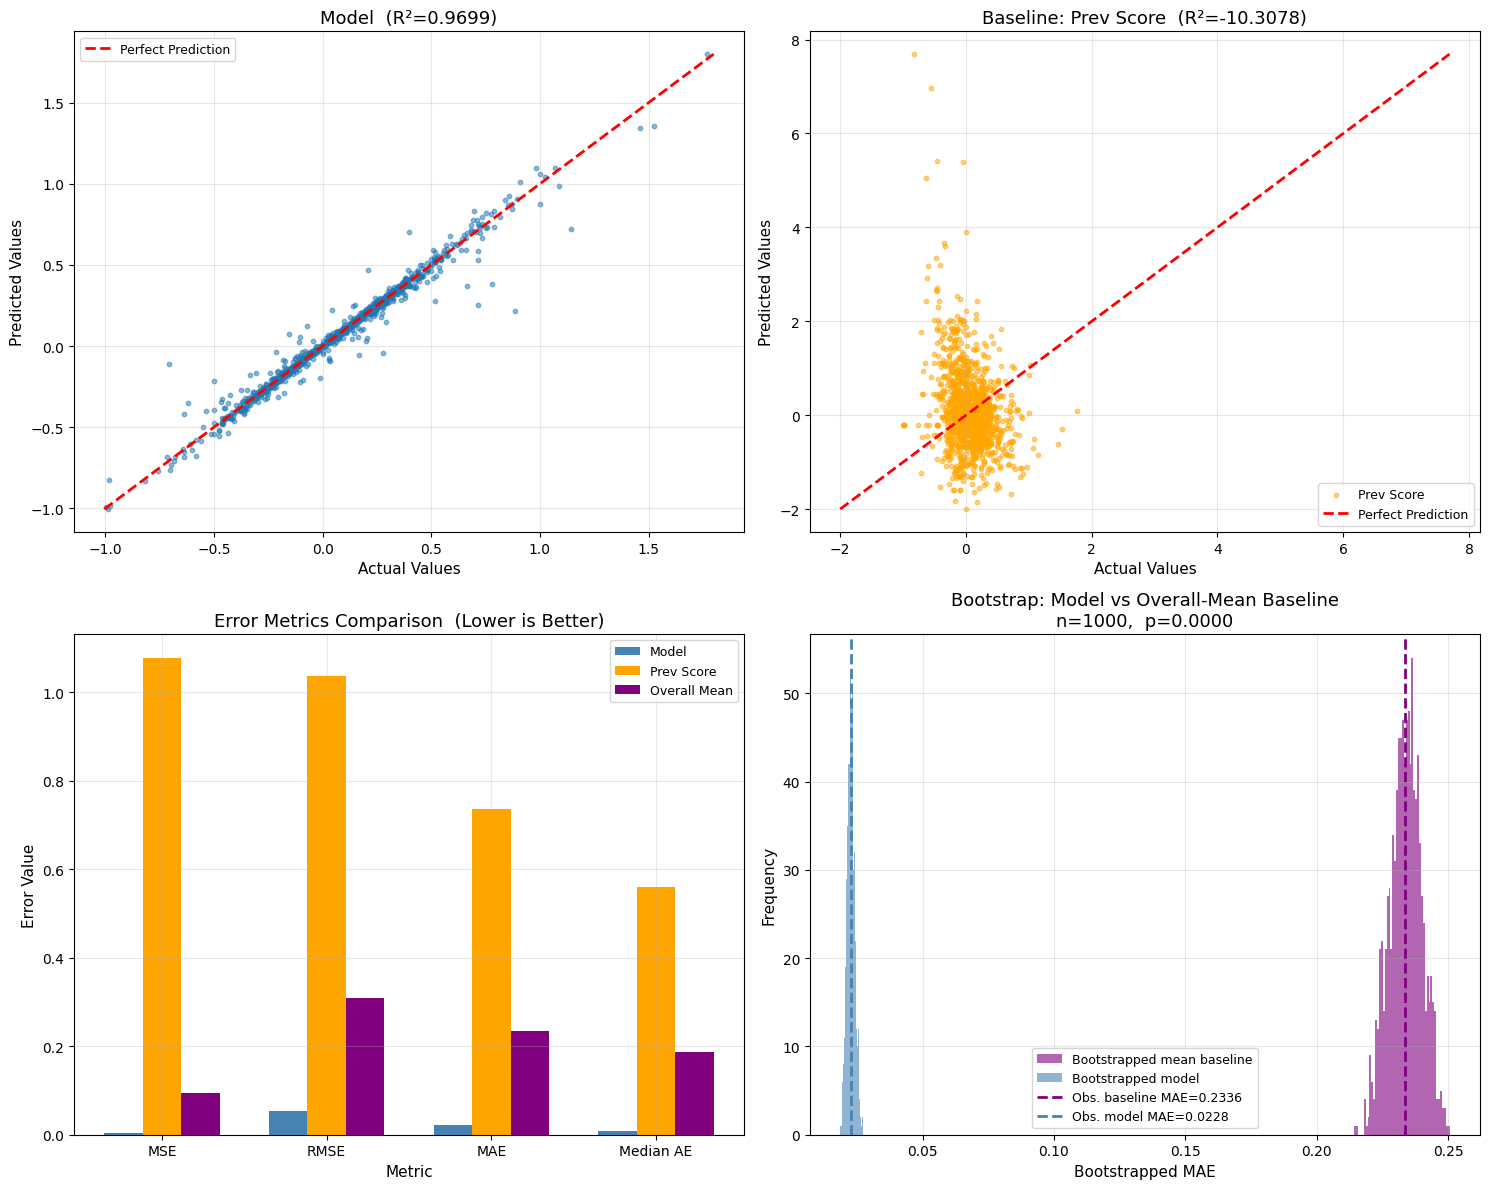

{'model': {'predictions': array([ 0.3039409 , -0.16598737, -0.09656705, ..., -0.53479916,
          0.37262478,  0.38570827], shape=(1157,), dtype=float32),
  'targets': array([ 0.3       , -0.15384616, -0.0952381 , ..., -0.4375    ,
          0.6666667 ,  0.7804878 ], shape=(1157,), dtype=float32),
  'metrics': {'mse': 0.002864021771682857,
   'rmse': 0.05351655605214948,
   'mae': 0.022765326836486906,
   'mape': 2043122.3516733323,
   'r2': 0.9699468496058884,
   'median_ae': 0.009062975645065308}},
 'prev_score_baseline': {'predictions': array([-0.13852996,  1.46886313, -1.03715885, ...,  1.25618017,
         -0.20601591, -1.1434238 ], shape=(1157,)),
  'targets': array([ 0.30000001, -0.15384616, -0.0952381 , ..., -0.4375    ,
          0.66666669,  0.78048778], shape=(1157,)),
  'metrics': {'mse': 1.077620363686984,
   'rmse': 1.0380849501302791,
   'mae': 0.7356738148714145,
   'mape': 206293383.15525243,
   'r2': -10.307835428434151,
   'median_ae': 0.5600439608097076}},
 'overa

In [26]:
evaluate_mlp(model_overfit, overfit_loader, device, compare_baselines=True)

### Single Run

In [7]:
def start_training(params):
    epochs = 500
    model_path = params["model_path"]

    weight_decay = params["weight_decay"]
    lr = params["lr"]
    batch_size = params["batch_size"]
    dropout = params["dropout"]

    model = MLP(dropout=dropout).to(device)

    _train_loader, _val_loader, _test_loader = get_data_loaders(
        data_dict, train_years, val_years, test_years, batch_size=batch_size
    )

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    early_stopper = EarlyStopping(patience=30, path=model_path, printing=True)
    criterion = nn.L1Loss().to(device)

    train_losses, val_losses = train_model_mlp(
        epochs,
        model,
        optimizer,
        criterion,
        _train_loader,
        _val_loader,
        early_stopper,
        device,
        printing=True,
    )
    results = evaluate_mlp(model, _val_loader, device, printing=True)

    return train_losses, val_losses, results, model


Train dataset size: 10006
Validation dataset size: 3852
Test dataset size: 5684
Epoch: 1, Training Loss: 0.2546, Validation Loss: 0.2278
Validation loss decreased (0.227819 --> 0.227819).  Saving model ...
Epoch: 2, Training Loss: 0.2421, Validation Loss: 0.2249
Validation loss decreased (0.227819 --> 0.224893).  Saving model ...
Epoch: 3, Training Loss: 0.2390, Validation Loss: 0.2239
Validation loss decreased (0.224893 --> 0.223921).  Saving model ...
Epoch: 4, Training Loss: 0.2373, Validation Loss: 0.2222
Validation loss decreased (0.223921 --> 0.222189).  Saving model ...
Epoch: 5, Training Loss: 0.2331, Validation Loss: 0.2194
Validation loss decreased (0.222189 --> 0.219402).  Saving model ...
Epoch: 6, Training Loss: 0.2293, Validation Loss: 0.2188
Validation loss decreased (0.219402 --> 0.218840).  Saving model ...
Epoch: 7, Training Loss: 0.2291, Validation Loss: 0.2171
Validation loss decreased (0.218840 --> 0.217134).  Saving model ...
Epoch: 8, Training Loss: 0.2269, Valid

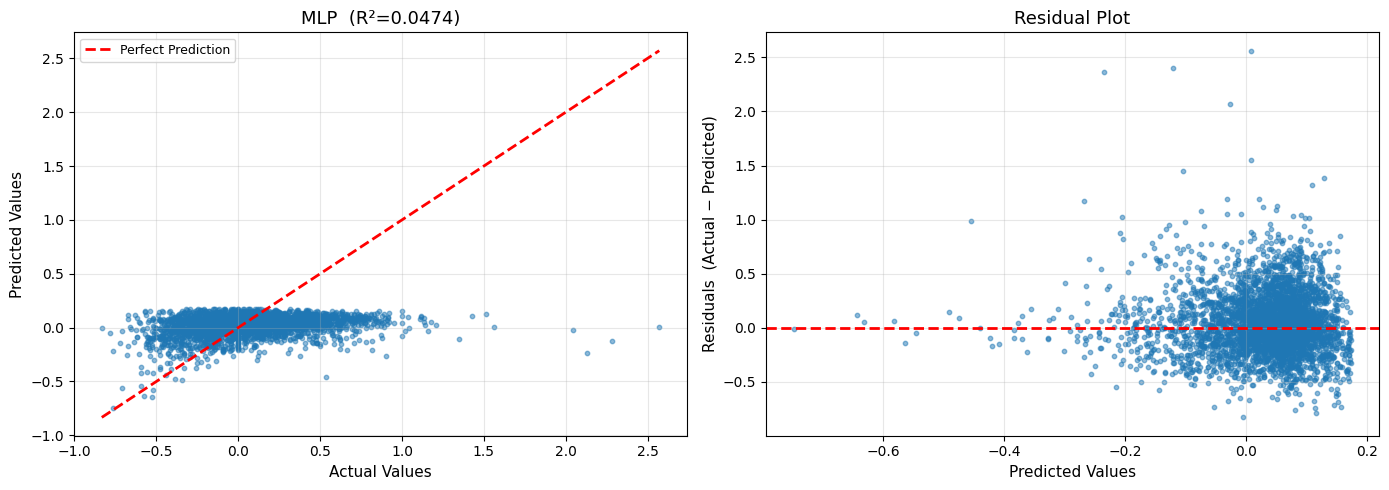

In [9]:
params = {
    "weight_decay": 1e-5,
    "lr": 0.0001,
    "batch_size": 64,
    "dropout": 0.2,
    "model_path": "pt_models/mlp_ipc_mean_post2006_change.pt",
}

train_losses, val_losses, results, model = start_training(params)


### Hyperparameter Optimization

In [ ]:
N_TRIALS = 30  # increase for a more thorough search
MAX_EPOCHS = 150  # epochs per trial (early-stopping can cut this short)
PATIENCE = 20  # early-stopping patience during tuning


def objective(trial):
    epochs = 200
    model_path = "pt_models/mlp.pt"

    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-2, log=True)
    lr = trial.suggest_float("lr", 1e-6, 1e-1, log=True)
    batch_size = trial.suggest_int("batch_size", 8, 128, step=8)
    dropout = trial.suggest_float("dropout", 0.1, 0.5, step=0.1)

    model = MLP(dropout=dropout).to(device)

    _train_loader, _val_loader, _test_loader = get_data_loaders(
        data_dict, train_years, val_years, test_years, batch_size=batch_size
    )

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    _early_stopper = EarlyStopping(patience=30, path=model_path, printing=False)
    criterion = nn.L1Loss().to(device)

    train_model_mlp(
        epochs,
        model,
        optimizer,
        criterion,
        _train_loader,
        _val_loader,
        _early_stopper,
        device=device,
        printing=False,
    )
    best_val_loss = _early_stopper.best_loss

    # Report to Optuna and allow pruning at the end of training
    trial.report(best_val_loss, step=MAX_EPOCHS)

    # Clean up the checkpoint file
    if os.path.exists(model_path):
        os.remove(model_path)

    return best_val_loss


study = optuna.create_study(
    study_name="MLP",
    storage="sqlite:///mlp.db",
    direction="minimize",
    load_if_exists=False,
)
optuna.logging.set_verbosity(optuna.logging.WARNING)  # keep output clean

print(f"Starting Optuna search: {N_TRIALS} trials, up to {MAX_EPOCHS} epochs each.")
print("=" * 60)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True,
)

print("Best trial:")
print(study.best_trial.params)


Starting Optuna search: 30 trials, up to 150 epochs each.


  0%|          | 0/30 [00:00<?, ?it/s]

Train dataset size: 10006
Validation dataset size: 3852
Test dataset size: 5684
Train dataset size: 10006
Validation dataset size: 3852
Test dataset size: 5684
Train dataset size: 10006
Validation dataset size: 3852
Test dataset size: 5684
Train dataset size: 10006
Validation dataset size: 3852
Test dataset size: 5684
Train dataset size: 10006
Validation dataset size: 3852
Test dataset size: 5684
Train dataset size: 10006
Validation dataset size: 3852
Test dataset size: 5684
Train dataset size: 10006
Validation dataset size: 3852
Test dataset size: 5684
Train dataset size: 10006
Validation dataset size: 3852
Test dataset size: 5684
Train dataset size: 10006
Validation dataset size: 3852
Test dataset size: 5684
Train dataset size: 10006
Validation dataset size: 3852
Test dataset size: 5684
Train dataset size: 10006
Validation dataset size: 3852
Test dataset size: 5684
Train dataset size: 10006
Validation dataset size: 3852
Test dataset size: 5684
Train dataset size: 10006
Validation dat

### Final Training

In [5]:
# get best parameters and result from optuna study
study = optuna.load_study(study_name="MLP", storage="sqlite:///mlp.db")

best_params = study.best_trial.params
best_value = study.best_trial.value

print("Best Parameters:", best_params)
print("Best Value:", best_value)


Best Parameters: {'weight_decay': 4.151474779611164e-05, 'lr': 1.4597699673474687e-05, 'batch_size': 104, 'dropout': 0.30000000000000004}
Best Value: 0.21109761278095998


Train dataset size: 10006
Validation dataset size: 3852
Test dataset size: 5684
Removing existing model at: pt_models/mlp_best.pt
Epoch: 1, Training Loss: 0.2590, Validation Loss: 0.2241
Validation loss decreased (0.224053 --> 0.224053).  Saving model ...
Epoch: 2, Training Loss: 0.2511, Validation Loss: 0.2241
Epoch: 3, Training Loss: 0.2459, Validation Loss: 0.2262
Epoch: 4, Training Loss: 0.2458, Validation Loss: 0.2261
Epoch: 5, Training Loss: 0.2437, Validation Loss: 0.2259
Epoch: 6, Training Loss: 0.2439, Validation Loss: 0.2257
Epoch: 7, Training Loss: 0.2425, Validation Loss: 0.2249
Epoch: 8, Training Loss: 0.2416, Validation Loss: 0.2240
Epoch: 9, Training Loss: 0.2413, Validation Loss: 0.2238
Validation loss decreased (0.224053 --> 0.223822).  Saving model ...
Epoch: 10, Training Loss: 0.2393, Validation Loss: 0.2242
Epoch: 11, Training Loss: 0.2403, Validation Loss: 0.2223
Validation loss decreased (0.223822 --> 0.222350).  Saving model ...
Epoch: 12, Training Loss: 0.2391, 

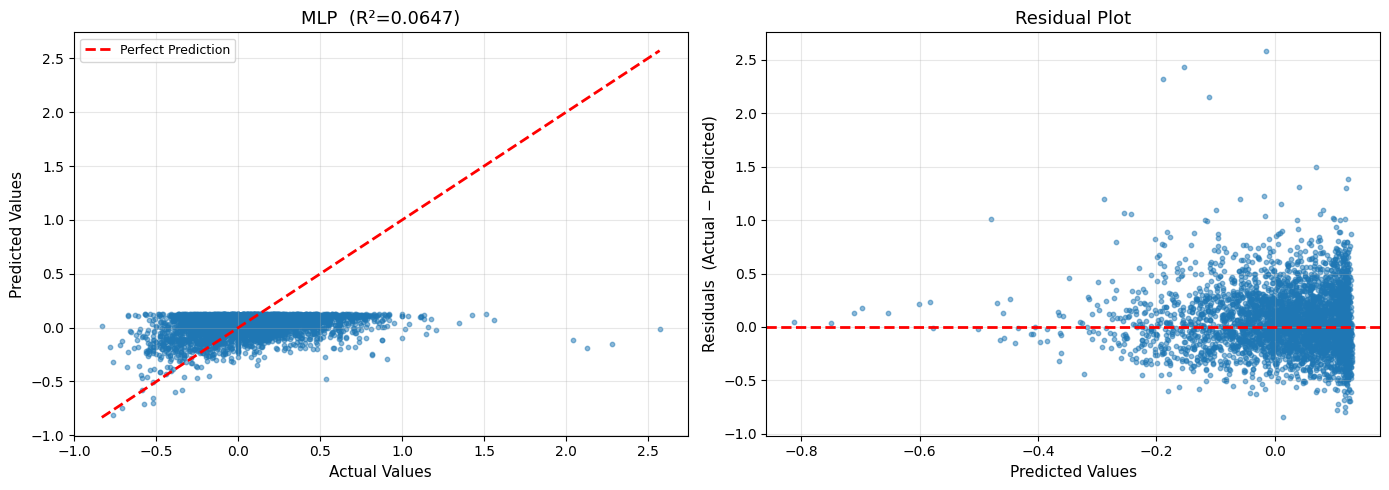

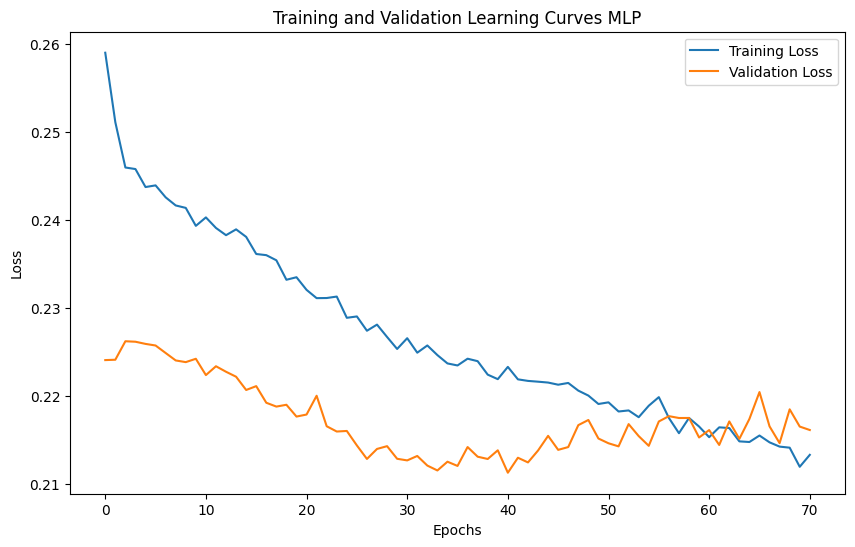

In [ ]:
best_params["model_path"] = "pt_models/mlp_best.pt"

train_losses, val_losses, results, model = start_training(best_params)


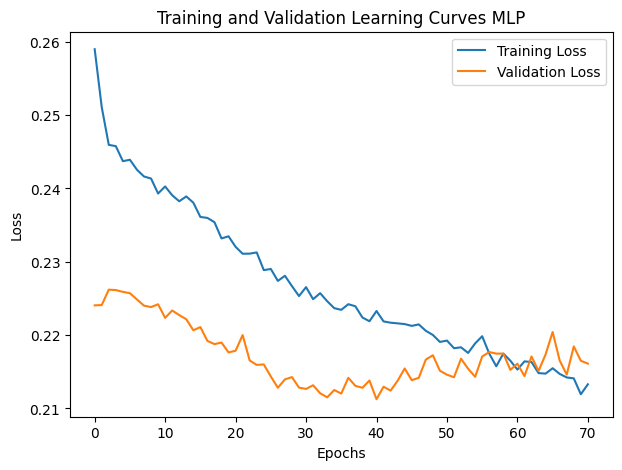

In [12]:
# plot loss curves
plt.figure(figsize=(7, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Learning Curves MLP")
plt.legend()
plt.show()

## Evaluation

Evaluating on test set...

MODEL: MLP
Number of predictions:            5684
Mean Squared Error (MSE):         0.085371
Root Mean Squared Error (RMSE):   0.292182
Mean Absolute Error (MAE):        0.221784
Median Absolute Error:            0.178535
Mean Absolute Percentage Error:   20038130.46%
R² Score:                         0.021704

BASELINE: Previous Year's Score (Persistence)
Number of predictions:            5684
Mean Squared Error (MSE):         0.758449
Root Mean Squared Error (RMSE):   0.870890
Mean Absolute Error (MAE):        0.628311
Median Absolute Error:            0.456593
Mean Absolute Percentage Error:   128512978.23%
R² Score:                         -7.691381

BASELINE: Overall Mean
Number of predictions:            5684
Mean Squared Error (MSE):         0.087265
Root Mean Squared Error (RMSE):   0.295406
Mean Absolute Error (MAE):        0.223210
Median Absolute Error:            0.180072
Mean Absolute Percentage Error:   884701.48%
R² Score:                      

/tmp/ipykernel_349/881834920.py:2: UserWarning: train_mean not provided for MLP overall-mean baseline. Falling back to the test-set mean — this leaks label information.
  results = evaluate_mlp(


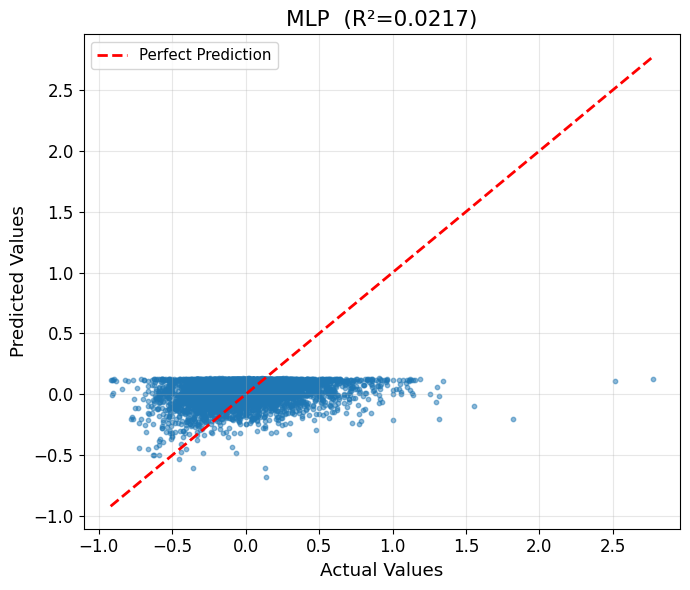

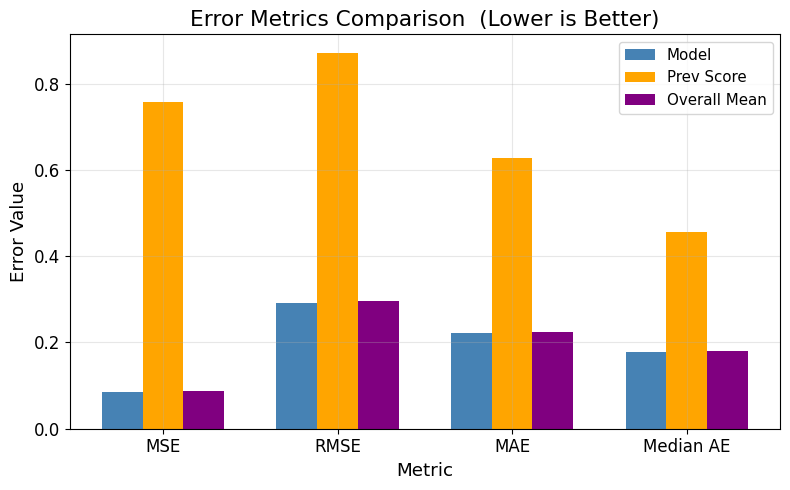

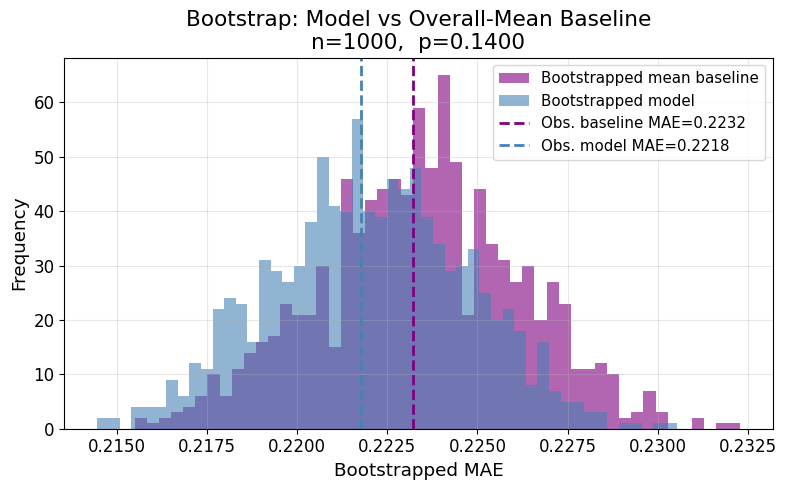

In [13]:
print("Evaluating on test set...")
results = evaluate_mlp(
    model,
    test_loader,
    device,
    compare_baselines=True,
    printing=True,
    export=True,
    export_dir="mlp_export",
    font_scale=1.2,
)